## Paso 0: dependencias y dataset


In [ ]:
%pip install -q -U openai-agents pandas matplotlib


## Paso 1: importa utilidades del SDK


In [3]:
import io, contextlib
from typing import Annotated 
from agents import Agent, Runner, function_tool, WebSearchTool

## Paso 2: define herramientas


In [4]:
@function_tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
) -> str:
    """Use this to execute any python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    buf = io.StringIO()
    local_ns = {}
    try:
        with contextlib.redirect_stdout(buf):
            exec(code, {}, local_ns)
    except Exception as e:
        return f"Failed to execute. Error: {e!r}"
    stdout = buf.getvalue().strip()
    result_str = f"Successfully executed:\n```python\n{code}\n```"
    if stdout:
        result_str += f"\nStdout:\n{stdout}"
    return result_str


## Paso 3: crea el agente


In [5]:
agent = Agent(
    name='CSVAnalyst',
    instructions=(
        'Eres un analista de mercado senior. Tienes acceso a internet y a ejecución de código Python.'
        'Tu tarea es realizar análisis sobre lo que se te indique.'
        'Los gráficos que se te pidan deben generarse usando matplotlib y mostrarse al usuario.'
    ),
    tools=[
        python_repl_tool,
        WebSearchTool()],
    model='gpt-4.1',
)


## Paso 4: pruebas de consulta


In [6]:
q1 = """
¿Cuáles han sido los principales hitos en 2025 para la empresa Apple Inc.? 
"""
res = await Runner.run(agent, q1)
print(res.final_output)

Aquí tienes un análisis detallado en español sobre los principales hitos de Apple Inc. durante 2025. Cada logro está respaldado por múltiples fuentes confiables para garantizar precisión y contexto:

##  Inversión histórica en EE. UU.: más de 500 mil millones de dólares  
- El **24 de febrero de 2025**, Apple anunció su mayor compromiso de inversión en EE. UU., destinando más de **500 mil millones de dólares durante los próximos cuatro años**. Este capital se enfocará en manufactura avanzada, IA, ingeniería de silicio, infraestructura y formación de talento técnico. Entre las iniciativas incluidas:
  - Duplicar el Fondo Avanzado de Manufactura de EE. UU.
  - Construcción de una nueva fábrica en Houston para servidores que soporten *Apple Intelligence*.
  - Creación de una academia de manufactura en Detroit, con cursos presenciales y online, y colaboración con universidades como Michigan State y UCLA. ([apple.com](https://www.apple.com/newsroom/2025/02/apple-will-spend-more-than-500-bil

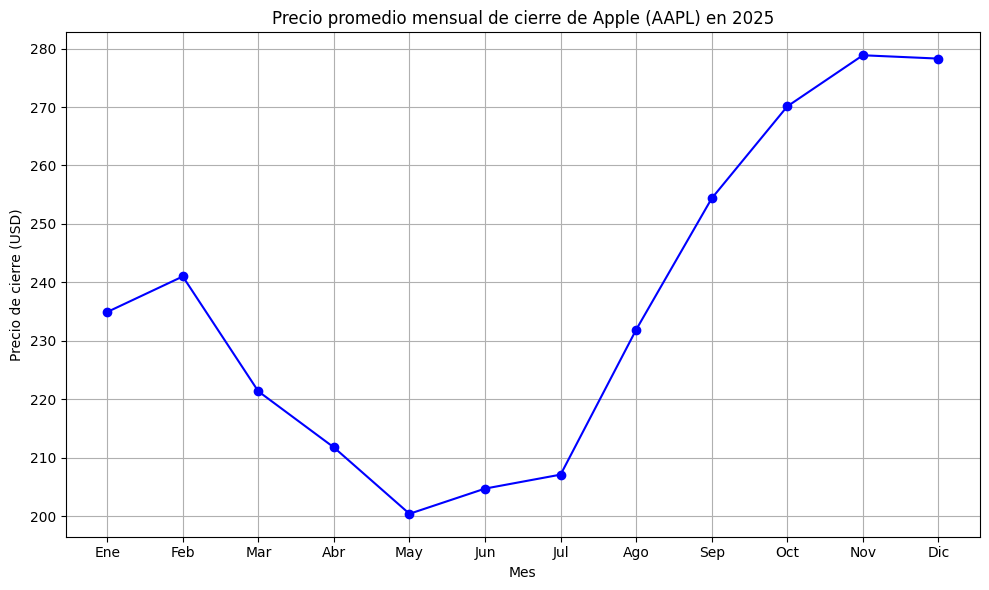

Aquí tienes el gráfico con el precio promedio mensual de cierre de las acciones de Apple (AAPL) durante 2025.

Como puedes observar, el precio inició el año en niveles altos, tuvo una corrección entre marzo y mayo, y después mostró una recuperación sostenida, finalizando el año en máximos históricos de aproximadamente 278 USD por acción.

¿Te gustaría que realice un análisis complementario, como comparación con el S&P 500 o con otros gigantes tecnológicos?


In [7]:
q2 = res.to_input_list() + [
    {
        "role": "user", 
        "content": "Investiga cómo han evolucionado sus acciones en el 2025 y genera un gráfico con el precio promedio mensual"
    }
]
res2 = await Runner.run(agent, q2)
print(res2.final_output)

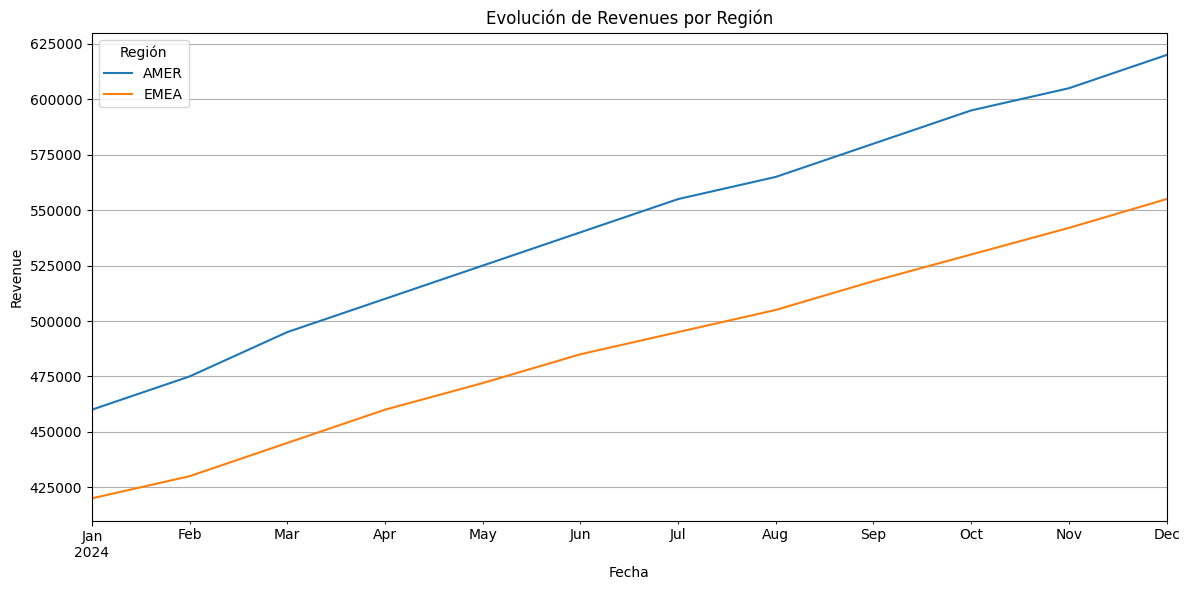

Aquí tienes el gráfico solicitado, donde se muestra la evolución de los revenues (ingresos) por región a lo largo del tiempo. Este gráfico permite identificar tendencias, estacionalidad o diferencias significativas entre regiones a lo largo del periodo analizado.

Si necesitas un análisis más detallado, como crecimiento porcentual, ranking por regiones o insights específicos, házmelo saber.


In [9]:
q = """
Hay un archivo CSV en el siguiente path: './data.csv'.
Analiza su contenido y genera un gráfico con la evolución de las revenues por region.
"""
res = await Runner.run(agent, q)
print(res.final_output)

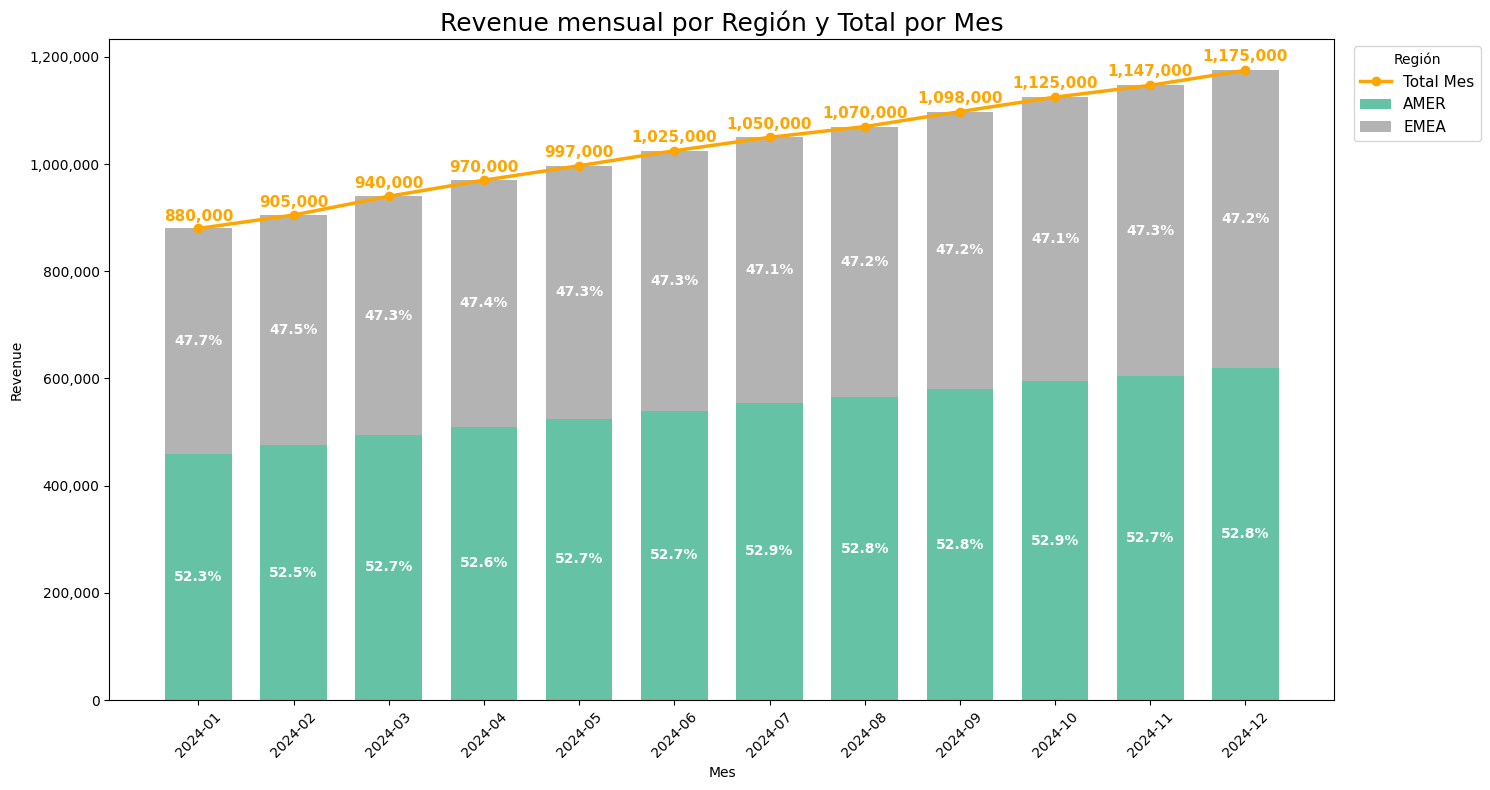

Aquí tienes el gráfico solicitado:

- Cada barra apilada muestra, para cada mes, la revenue de cada región con un color distinto.
- En el centro de cada segmento de barra se ve qué porcentaje representa cada región del total mensual.
- La línea naranja y los valores encima de cada barra indican la revenue total mensual, con formato legible (no notación científica).
- La leyenda y los ejes están claramente indicados, facilitando la lectura y comparación.

¿Necesitas el archivo del gráfico exportado o los datos en una tabla complementaria? ¿O deseas proceder con otro análisis?


In [14]:
q = res.to_input_list() + [
    {
        "role": "user",
        "content": """
        Genera un único gráfico de barras donde se vea, para cada mes, la revenue de cada 
        región y la revenue total del mes. Incluye etiquetas y leyendas para que se
        entienda bien el gráfico. Muestra en el mismo gráfico qué porcentaje representa
        cada región del total mensual. No uses notación científica, sino usa notación
        legible para el usuario.
        """
    }
]
res = await Runner.run(agent, q)
print(res.final_output)